In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/customers.csv')

print(df.shape)           # Should show (7043, 21)
print(df.head())
print(df['Churn'].value_counts())   # Check churn distribution

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [3]:
import sys
print(sys.version)
!{sys.executable} -m pip install seaborn


3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import seaborn as sns
print

<function print>

In [6]:
df = pd.read_csv('../data/raw/customers.csv')

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (7043, 21)

Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
 customerID   

In [7]:
# TotalCharges has spaces — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with 0 (new customers)
df['TotalCharges'].fillna(0, inplace=True)

# Convert Churn to binary 0/1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Fixed! Churn rate:", round(df['Churn'].mean() * 100, 2), "%")

Fixed! Churn rate: 26.54 %


C:\Users\riyar\AppData\Local\Temp\ipykernel_20764\3320960693.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


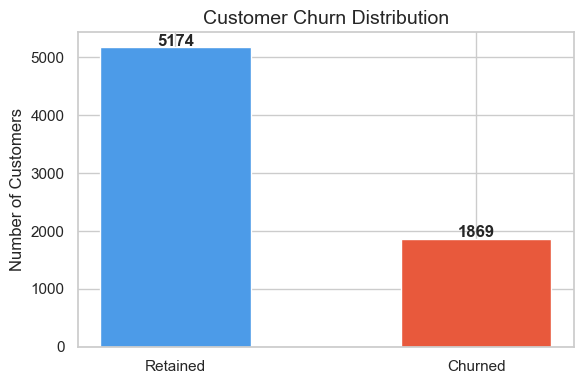

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

counts = df['Churn'].value_counts()
ax.bar(['Retained', 'Churned'], counts, color=['#4C9BE8', '#E8593C'], width=0.5)

for i, v in enumerate(counts):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')

ax.set_title('Customer Churn Distribution', fontsize=14)
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../reports/churn_distribution.png', dpi=150)
plt.show()

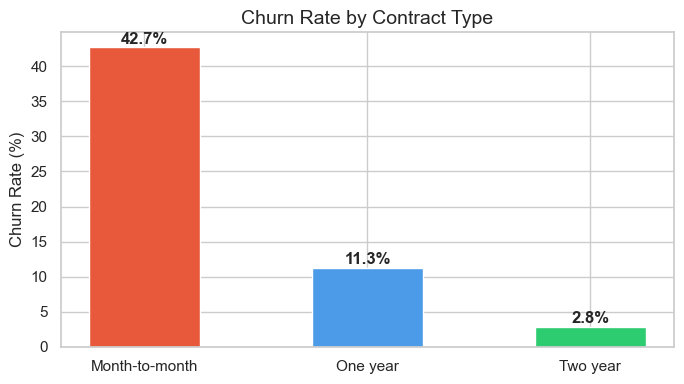

In [9]:
contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
contract_churn['Churn'] = contract_churn['Churn'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(contract_churn['Contract'], contract_churn['Churn'],
              color=['#E8593C', '#4C9BE8', '#2ECC71'], width=0.5)

for bar, val in zip(bars, contract_churn['Churn']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')

ax.set_title('Churn Rate by Contract Type', fontsize=14)
ax.set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('../reports/churn_by_contract.png', dpi=150)
plt.show()

C:\Users\riyar\AppData\Local\Temp\ipykernel_20764\4156218320.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby('tenure_group')['Churn'].mean() * 100


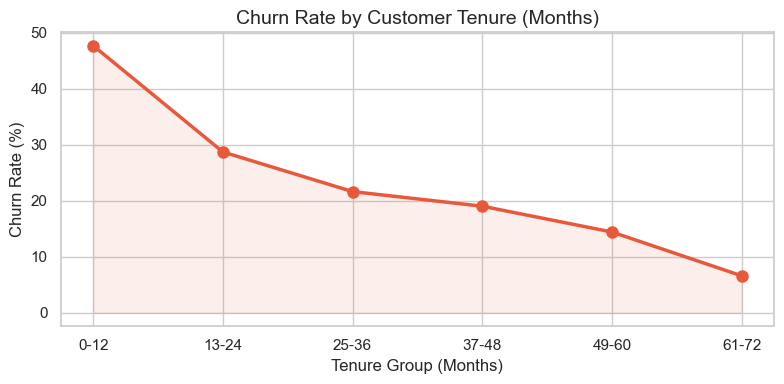

In [10]:
df['tenure_group'] = pd.cut(df['tenure'], 
                             bins=[0, 12, 24, 36, 48, 60, 72],
                             labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72'])

tenure_churn = df.groupby('tenure_group')['Churn'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tenure_churn.index, tenure_churn.values, marker='o', 
        color='#E8593C', linewidth=2.5, markersize=8)
ax.fill_between(range(len(tenure_churn)), tenure_churn.values, alpha=0.1, color='#E8593C')

ax.set_title('Churn Rate by Customer Tenure (Months)', fontsize=14)
ax.set_xlabel('Tenure Group (Months)')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticks(range(len(tenure_churn)))
ax.set_xticklabels(tenure_churn.index)
plt.tight_layout()
plt.savefig('../reports/churn_by_tenure.png', dpi=150)
plt.show()

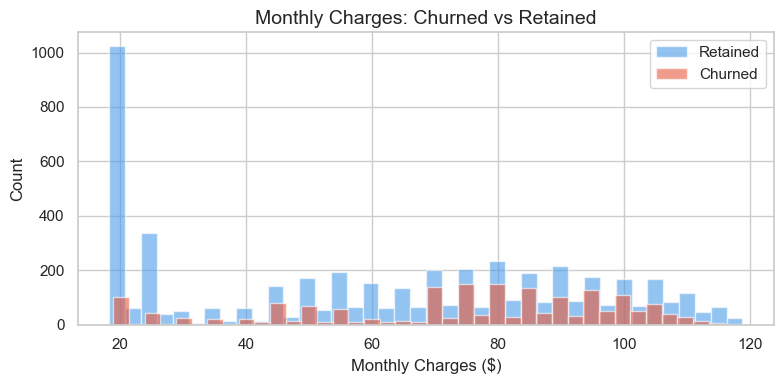

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df[df['Churn'] == 0]['MonthlyCharges'], bins=40, 
        alpha=0.6, color='#4C9BE8', label='Retained')
ax.hist(df[df['Churn'] == 1]['MonthlyCharges'], bins=40, 
        alpha=0.6, color='#E8593C', label='Churned')

ax.set_title('Monthly Charges: Churned vs Retained', fontsize=14)
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/charges_distribution.png', dpi=150)
plt.show()

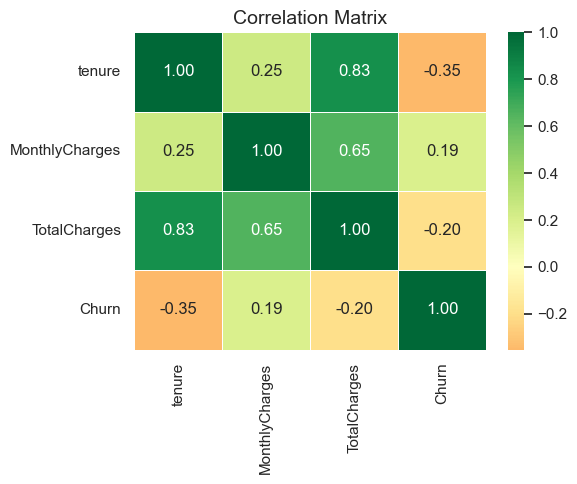

In [12]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, ax=ax, linewidths=0.5)

ax.set_title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150)
plt.show()

In [13]:
print("=" * 45)
print("       EDA SUMMARY — KEY INSIGHTS")
print("=" * 45)

churn_rate = df['Churn'].mean() * 100
print(f"\n Overall Churn Rate     : {churn_rate:.1f}%")

mtm = df[df['Contract'] == 'Month-to-month']['Churn'].mean() * 100
print(f" Month-to-Month Churn   : {mtm:.1f}%")

new_churn = df[df['tenure'] <= 12]['Churn'].mean() * 100
print(f" New Customer Churn     : {new_churn:.1f}%")

old_churn = df[df['tenure'] > 12]['Churn'].mean() * 100
print(f" Loyal Customer Churn   : {old_churn:.1f}%")

avg_charge_churned = df[df['Churn'] == 1]['MonthlyCharges'].mean()
avg_charge_retained = df[df['Churn'] == 0]['MonthlyCharges'].mean()
print(f" Avg Charge (Churned)   : ${avg_charge_churned:.2f}")
print(f" Avg Charge (Retained)  : ${avg_charge_retained:.2f}")

print("\n Charts saved to /reports/")
print("=" * 45)

       EDA SUMMARY — KEY INSIGHTS

 Overall Churn Rate     : 26.5%
 Month-to-Month Churn   : 42.7%
 New Customer Churn     : 47.4%
 Loyal Customer Churn   : 17.1%
 Avg Charge (Churned)   : $74.44
 Avg Charge (Retained)  : $61.27

 Charts saved to /reports/
